# Met-3DNet-VI v0.7 — Full Dataset Integration
**Datasets:** IEDB v3 + TumorAgDB1.0 + TESLA (Wells et al., 2020) + NCI/HiTIDE (Müller et al., 2023)

**Key changes vs v0.6:**
- Added TESLA: 41 IFN-γ ELISpot + multimer validated immunogenic neo-peptides (Wells et al., 2020)
- Added NCI+HiTIDE: 176 IFN-γ ELISpot validated CD8+ T cell immunogenic neo-peptides (Müller et al., 2023)
- Scratch training with correct pos_weight (no warm-start distribution mismatch)
- lambda2=0.0 (functional CE disabled — r(lambda2, AUC)=-0.91 in v0.4)
- Total immunogenic labels: ~10,700 | New IFN-γ validated additions: +217

## Cell 1 — Setup

In [1]:
import os, sys, glob, shutil, subprocess, re
import warnings; warnings.filterwarnings("ignore")

KAGGLE   = os.path.exists("/kaggle/input")
WORK_DIR = "/kaggle/working" if KAGGLE else os.getcwd()
MODELS_DIR = os.path.join(WORK_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

subprocess.run(["pip","install","pyarrow","torch-geometric",
                "scikit-learn","openpyxl","--quiet"], check=True)

import torch, numpy as np, pandas as pd
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

INPUT_ROOTS = [
    "/kaggle/input/tesla-nci-labels",  # TESLA + NCI labels
    "/kaggle/input/tesla-labels",       # TESLA (fallback)
    "/kaggle/working/data",              # local uploads
    ]
if KAGGLE:
    for ds in os.listdir("/kaggle/input"):
        INPUT_ROOTS.append(os.path.join("/kaggle/input", ds))

def find_file(name, roots=None):
    """Find a file by name across all dataset roots (recursive)."""
    search_roots = roots or INPUT_ROOTS or [WORK_DIR]
    for root in search_roots:
        for p in glob.glob(os.path.join(root, "**", name), recursive=True):
            if os.path.exists(p):
                return p
    return None

# Copy best_model.pt — recursive search so nested paths work
ckpt_dst = os.path.join(MODELS_DIR, "best_model.pt")
if not os.path.exists(ckpt_dst):
    hit = find_file("best_model.pt")
    if hit:
        shutil.copy2(hit, ckpt_dst)
        print(f"Copied best_model.pt from: {hit}")
    else:
        print("WARNING: best_model.pt not found — training will start from scratch.")
        print("  Add your Kaggle dataset containing best_model.pt to enable warm start.")
else:
    print(f"Checkpoint ready: {ckpt_dst}")

print(f"Setup complete | {len(INPUT_ROOTS)} dataset(s) mounted")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00
Device: cuda
Copied best_model.pt from: /kaggle/input/datasets/neetuaashi/iedb-org-database-export/best_model.pt
Setup complete | 1 dataset(s) mounted


## Cell 2 — Audit TumorAgDB1.0 Files
Reads every xlsx file, prints its sheets and columns, identifies peptide + HLA + label columns.
Run this first to understand the data before extraction.

In [2]:
from openpyxl import load_workbook

# All TumorAgDB1.0 file names (from the dataset description)
XLSX_NAMES = [
    "All the data on T cell activation experiments.xlsx",
    "NeoAntigen-PubData 2024-2025.xlsx",
    "Non-immunogenic Mutation Dataset.xlsx",
    "T-mTSA-negative-mouse.xlsx",
    "T-mTSA-postive-Homo sapiens-812.xlsx",
    "T-mTSA-postive-mouse.xlsx",
    "Tumor Protein Database.xlsx",
    "Validated Immunogenic Neoantigen Data.xlsx",
    "immunogenic Mutation Dataset.xlsx",
    "immunogenic Neo-peptide Dataset.xlsx",
    "mouse-MHC I-MB49-B16F10-P815-BBN963.xlsx",
    "mouse-MHC II-MB49-B16F10.xlsx",
]

# Keywords to look for in column names
PEP_KEYS  = ["peptide","sequence","epitope","neo","mutation","mutant","antigen"]
HLA_KEYS  = ["hla","mhc","allele","restriction","locus"]
LABEL_KEYS= ["immuno","response","positive","negative","label","class",
              "activation","ifn","elispot","validated","functional"]

def audit_xlsx(path):
    """Read xlsx and return sheet summary + column classifications."""
    wb = load_workbook(path, read_only=True, data_only=True)
    results = {}
    for sheet in wb.sheetnames:
        ws = wb[sheet]
        rows = list(ws.iter_rows(max_row=3, values_only=True))
        if not rows: continue
        header = [str(c).strip() if c else "" for c in rows[0]]
        sample  = rows[1] if len(rows) > 1 else []

        pep_cols   = [h for h in header if any(k in h.lower() for k in PEP_KEYS)]
        hla_cols   = [h for h in header if any(k in h.lower() for k in HLA_KEYS)]
        label_cols = [h for h in header if any(k in h.lower() for k in LABEL_KEYS)]

        results[sheet] = {
            "n_cols"     : len(header),
            "pep_cols"   : pep_cols[:5],
            "hla_cols"   : hla_cols[:5],
            "label_cols" : label_cols[:5],
            "header"     : header[:12],
            "sample"     : [str(v)[:40] if v else "" for v in (sample or [])[:8]],
        }
    wb.close()
    return results

print("Auditing TumorAgDB1.0 files...")
print("="*70)

AUDIT = {}
for fname in XLSX_NAMES:
    path = find_file(fname)
    if path is None:
        print(f"  NOT FOUND: {fname}")
        continue

    sz = os.path.getsize(path) / 1e6
    try:
        info = audit_xlsx(path)
        AUDIT[fname] = {"path": path, "size_mb": sz, "sheets": info}

        # Score usefulness
        has_pep   = any(s["pep_cols"]   for s in info.values())
        has_hla   = any(s["hla_cols"]   for s in info.values())
        has_label = any(s["label_cols"] for s in info.values())
        usability = sum([has_pep, has_hla, has_label])
        flag = "HIGH" if usability == 3 else "MED" if usability >= 2 else "LOW"

        print(f"\n[{flag}] {fname}  ({sz:.1f} MB)")
        for sheet, s in info.items():
            print(f"  Sheet: {sheet}")
            print(f"    Peptide cols : {s['pep_cols'] or 'none found'}")
            print(f"    HLA cols     : {s['hla_cols'] or 'none found'}")
            print(f"    Label cols   : {s['label_cols'] or 'none found'}")
            print(f"    All cols     : {s['header']}")
    except Exception as e:
        print(f"  ERROR reading {fname}: {e}")

print("\nAudit complete ✓")

# ─── TESLA integration (Wells et al., 2020; Cell 183:818-834) ───────────────
def load_tesla(roots):
    for root in roots:
        for name in ["tesla_immunogenicity_labels.csv", "tesla_labels.csv"]:
            p = os.path.join(root, name)
            if os.path.exists(p):
                df = pd.read_csv(p)
                print(f"  TESLA loaded: {len(df)} rows from {p}")
                return df
    print("  WARNING: TESLA labels not found — skipping")
    return None

# ─── NCI/HiTIDE integration (Müller et al., 2023; Immunity 56:2650) ─────────
def load_nci(roots):
    for root in roots:
        for name in ["nci_muller2023_labels.csv", "nci_hitide_labels.csv"]:
            p = os.path.join(root, name)
            if os.path.exists(p):
                df = pd.read_csv(p)
                print(f"  NCI/HiTIDE loaded: {len(df)} rows from {p}")
                return df
    print("  WARNING: NCI labels not found — skipping")
    return None

def standardise_external(df, source_name):
    """Convert TESLA/NCI CSV to standard parquet schema for merging."""
    out = pd.DataFrame()
    out["peptide"]          = df["peptide"].str.strip().str.upper()
    out["hla_allele"]       = df["hla_allele"].str.strip()
    out["immunogenicity"]   = df["immunogenicity"].astype(int)
    out["functional_class"] = df.get("functional_class", df["immunogenicity"].apply(lambda x: 2 if x==1 else 0))
    out["source"]           = source_name
    # Keep length filter consistent
    out["seq_len"]          = out["peptide"].str.len()
    out = out[(out["seq_len"] >= 8) & (out["seq_len"] <= 14)]
    out = out.drop(columns=["seq_len"])
    out = out.dropna(subset=["peptide","hla_allele"])
    out = out.drop_duplicates(subset=["peptide","hla_allele"])
    return out

print("\nLoading external validation datasets...")
tesla_df = load_tesla(INPUT_ROOTS + ["/mnt/user-data/uploads", "/kaggle/working"])
nci_df   = load_nci(INPUT_ROOTS + ["/mnt/user-data/uploads", "/kaggle/working"])


Auditing TumorAgDB1.0 files...

[HIGH] All the data on T cell activation experiments.xlsx  (13.8 MB)
  Sheet: Sheet1
    Peptide cols : ['Antigen_Name', 'Epitope_Antigen_IRI', 'Epitope_Organism', 'Length_of_Peptide', 'Peptide']
    HLA cols     : ['MHC_Allele', 'MHC_Type']
    Label cols   : ['immunogenicity']
    All cols     : ['Antigen_Name', 'Assay_Group', 'Assay_Units', 'Epitope_Antigen_IRI', 'Epitope_Organism', 'Length_of_Peptide', 'MHC_Allele', 'MHC_Type', 'Peptide', 'Protein_IRI', 'Qualitative_Measure', 'Reference']

[LOW] NeoAntigen-PubData 2024-2025.xlsx  (0.8 MB)

[HIGH] Non-immunogenic Mutation Dataset.xlsx  (5.7 MB)
  Sheet: Sheet1
    Peptide cols : ['aa_mutant', 'mutant_seq', 'mutation_type', 'nb_same_mutation_Intogen', 'nb_mutations_in_gene_Intogen']
    HLA cols     : ['COUNT_MUT_RANK_CI_MIXMHC', 'COUNT_MUT_RANK_CI_netMHCpan', 'MIN_MUT_RANK_CI_MIXMHC', 'WT_BEST_RANK_CI_MIXMHC']
    Label cols   : ['response_type', 'immunogenicity']
    All cols     : ['dataset', 'respo

## Cell 3 — Extract Functional Labels from Each File
After reviewing the audit output above, edit the column mappings below if needed.
The defaults are best guesses based on TumorAgDB1.0 standard schema.

In [3]:
VALID_AA    = set("ACDEFGHIKLMNPQRSTVWY")
HLA_PATTERN = re.compile(r"HLA-[ABC]\*\d{2}:\d{2}")

def valid_pep(seq, mn=8, mx=14):
    if not isinstance(seq, str): return False
    s = seq.strip().upper()
    return mn <= len(s) <= mx and all(c in VALID_AA for c in s)

def norm_hla(s):
    if not isinstance(s, str): return None
    s = s.strip()
    m = HLA_PATTERN.search(s)
    if m: return m.group()
    fixed = re.sub(r"^(A|B|C)(\*?)(\d{2})(\:?)(\d{2})$",
                   lambda m: f"HLA-{m.group(1)}*{m.group(3)}:{m.group(5)}", s)
    m = HLA_PATTERN.search(fixed)
    return m.group() if m else None

def find_col_exact(df, priority_names):
    """
    Exact name priority lookup (case-insensitive).
    Do NOT use substring matching — 'peptide' as a substring
    matches 'Length_of_Peptide' before 'Peptide', which was the
    bug causing zero records in every previous extraction attempt.
    """
    col_map = {c.lower(): c for c in df.columns}
    for name in priority_names:
        if name.lower() in col_map:
            return col_map[name.lower()]
    return None

def extract_standard(path, functional_class, source_tag):
    """
    Standard TumorAgDB schema: Peptide + MHC_Allele + immunogenicity.
    Files: T-mTSA-positive-812, Validated Immunogenic, T cell activation.
    """
    records = []
    try:
        xl = pd.ExcelFile(path, engine="openpyxl")
    except Exception as e:
        print(f"    Cannot open: {e}"); return pd.DataFrame()

    for sheet in xl.sheet_names:
        try: df = xl.parse(sheet)
        except Exception: continue
        if len(df) == 0: continue

        pep_col = find_col_exact(df, ["Peptide", "Epitope", "peptide", "epitope"])
        hla_col = find_col_exact(df, ["MHC_Allele", "HLA_Allele", "MHC Allele",
                                       "Allele", "allele"])
        lbl_col = find_col_exact(df, ["immunogenicity", "Qualitative_Measure",
                                       "response_type", "ELISpot_score"])
        if pep_col is None:
            print(f"    [{sheet}] no peptide column — skip"); continue

        n0 = len(records)
        for _, row in df.iterrows():
            pep = str(row.get(pep_col, "")).strip().upper()
            if not valid_pep(pep): continue
            if lbl_col is not None:
                val = str(row.get(lbl_col, "")).strip().lower()
                if functional_class == 2 and val in ("0","negative","non-immunogenic","no"): continue
                if functional_class == 0 and val in ("1","positive","immunogenic","yes"): continue
            hla = None
            if hla_col: hla = norm_hla(str(row.get(hla_col, "")))
            if hla is None:
                for col in df.columns:
                    cand = norm_hla(str(row.get(col, "")))
                    if cand: hla = cand; break
            hla = hla or "HLA-A*02:01"
            records.append({"peptide": pep, "hla_allele": hla,
                             "functional_class": functional_class,
                             "immunogenicity": 1 if functional_class in [1,2] else 0,
                             "source": source_tag, "peptide_len": len(pep)})
        print(f"    [{sheet}] pep={pep_col!r} hla={hla_col!r} lbl={lbl_col!r} "
              f"-> {len(records)-n0} records")

    return pd.DataFrame(records)

def extract_mutation(path, functional_class, source_tag):
    """
    NCI-harmonised mutation files: aa_mutant is a 25-mer centred on
    the mutation. Extract 9/10-mer windows spanning the centre.
    """
    records = []
    try:
        xl = pd.ExcelFile(path, engine="openpyxl")
    except Exception as e:
        print(f"    Cannot open: {e}"); return pd.DataFrame()

    for sheet in xl.sheet_names:
        if "description" in str(sheet).lower(): continue
        try: df = xl.parse(sheet)
        except Exception: continue
        if len(df) == 0: continue

        mut_col  = find_col_exact(df, ["aa_mutant","mutant_seq","Peptide","epitope"])
        hla_col  = find_col_exact(df, ["mutant_best_alleles",
                                        "mutant_best_alleles_netMHCpan","MHC_Allele"])
        resp_col = find_col_exact(df, ["immunogenicity","response_type"])
        if mut_col is None:
            print(f"    [{sheet}] no mutation column — skip"); continue

        n0 = len(records)
        for _, row in df.iterrows():
            raw = str(row.get(mut_col, "")).strip().upper()
            if not raw or raw == "NAN": continue
            if resp_col is not None:
                val = str(row.get(resp_col, "")).strip().lower()
                if functional_class == 2 and val in ("0","negative","no"): continue
                if functional_class == 0 and val in ("1","positive","yes"): continue
            if valid_pep(raw):
                candidates = [raw]
            elif len(raw) >= 17:
                centre = len(raw) // 2
                candidates = []
                for plen in [9, 10]:
                    for start in range(max(0, centre-plen+1),
                                       min(centre+1, len(raw)-plen+1)):
                        c = raw[start:start+plen]
                        if valid_pep(c): candidates.append(c)
                candidates = list(dict.fromkeys(candidates))
            else:
                continue
            hla = None
            if hla_col:
                for part in re.split(r"[;,\s]+", str(row.get(hla_col,"")).strip()):
                    hla = norm_hla(part.strip())
                    if hla: break
            hla = hla or "HLA-A*02:01"
            for pep in candidates:
                records.append({"peptide": pep, "hla_allele": hla,
                                 "functional_class": functional_class,
                                 "immunogenicity": 1 if functional_class in [1,2] else 0,
                                 "source": source_tag, "peptide_len": len(pep)})
        print(f"    [{sheet}] mut={mut_col!r} hla={hla_col!r} -> {len(records)-n0} records")

    return pd.DataFrame(records)

# ── Run extraction ────────────────────────────────────────────
print("Extracting records from TumorAgDB1.0...")
print()
dfs = []

STANDARD = [
    ("T-mTSA-postive-Homo sapiens-812.xlsx",     "tumoragdb_human_pos", 2),
    ("Validated Immunogenic Neoantigen Data.xlsx","tumoragdb_validated",  2),
    ("All the data on T cell activation experiments.xlsx","tumoragdb_tcell",2),
]
MUTATION = [
    ("immunogenic Neo-peptide Dataset.xlsx",  "tumoragdb_neo_pep",    2),
    ("immunogenic Mutation Dataset.xlsx",     "tumoragdb_immuno_mut", 2),
    ("Non-immunogenic Mutation Dataset.xlsx", "tumoragdb_nonimmuno",  0),
]

for fname, tag, fc in STANDARD:
    path = find_file(fname)
    print(f"  {fname[:55]}:")
    if not path: print("    NOT FOUND"); continue
    print(f"    {path}")
    df = extract_standard(path, fc, tag)
    if len(df): dfs.append(df); print(f"    -> {len(df):,} records ✓")
    else: print(f"    -> 0 records")

for fname, tag, fc in MUTATION:
    path = find_file(fname)
    print(f"  {fname[:55]}:")
    if not path: print("    NOT FOUND"); continue
    print(f"    {path}")
    df = extract_mutation(path, fc, tag)
    if len(df): dfs.append(df); print(f"    -> {len(df):,} records ✓")
    else: print(f"    -> 0 records")

print()
if not dfs:
    print("WARNING: 0 records extracted.")
    new_data = pd.DataFrame(columns=["peptide","hla_allele","functional_class",
                                      "immunogenicity","source","peptide_len"])
else:
    new_data = pd.concat(dfs, ignore_index=True)
    new_data = new_data.drop_duplicates(subset=["peptide","hla_allele"]).reset_index(drop=True)
    print(f"Total (after dedup): {len(new_data):,}")
    print(f"  Activating  (2): {(new_data['functional_class']==2).sum():,}")
    print(f"  Suppressive (1): {(new_data['functional_class']==1).sum():,}")
    print(f"  Non-immuno  (0): {(new_data['functional_class']==0).sum():,}")
    print(f"  HLA alleles    : {new_data['hla_allele'].nunique()}")

Extracting records from TumorAgDB1.0...

  T-mTSA-postive-Homo sapiens-812.xlsx:
    /kaggle/input/datasets/neetuaashi/tumoragdb1-0/T-mTSA-postive-Homo sapiens-812.xlsx
    [Sheet1] pep='Peptide' hla='MHC_Allele' lbl='immunogenicity' -> 8468 records
    -> 8,468 records ✓
  Validated Immunogenic Neoantigen Data.xlsx:
    /kaggle/input/datasets/neetuaashi/tumoragdb1-0/Validated Immunogenic Neoantigen Data.xlsx
    [Sheet1] pep='Peptide' hla='MHC_Allele' lbl='immunogenicity' -> 954 records
    -> 954 records ✓
  All the data on T cell activation experiments.xlsx:
    /kaggle/input/datasets/neetuaashi/tumoragdb1-0/All the data on T cell activation experiments.xlsx
    [Sheet1] pep='Peptide' hla='MHC_Allele' lbl='immunogenicity' -> 16748 records
    -> 16,748 records ✓
  immunogenic Neo-peptide Dataset.xlsx:
    /kaggle/input/datasets/neetuaashi/tumoragdb1-0/immunogenic Neo-peptide Dataset.xlsx
    [Sheet1] mut='aa_mutant' hla='mutant_best_alleles' -> 0 records
    -> 0 records
  immunogen

## Cell 4 — Encode New Records + Merge with Existing Splits
Applies the same AAindex encoding used during original training.
Matches new records to existing splits or creates a new supplementary training set.

In [4]:
# ── AAindex encoding (identical to training pipeline) ────────
AA_PROPS = {
    "A":[ 1.8, 0.0, 88.6,0.360, 8.1],"R":[-4.5, 1.0,173.4,0.530,10.5],
    "N":[-3.5, 0.0,114.1,0.460,11.6],"D":[-3.5,-1.0,111.1,0.510,13.0],
    "C":[ 2.5, 0.0,108.5,0.350, 5.5],"Q":[-3.5, 0.0,143.8,0.490,10.5],
    "E":[-3.5,-1.0,138.4,0.500,12.3],"G":[-0.4, 0.0, 60.1,0.540, 5.7],
    "H":[-3.2, 0.5,153.2,0.320, 8.4],"I":[ 4.5, 0.0,166.7,0.460, 5.2],
    "L":[ 3.8, 0.0,166.7,0.450, 4.9],"K":[-3.9, 1.0,168.6,0.470,10.1],
    "M":[ 1.9, 0.0,162.9,0.360, 5.4],"F":[ 2.8, 0.0,189.9,0.310, 5.2],
    "P":[-1.6, 0.0,112.7,0.000, 8.0],"S":[-0.8, 0.0, 89.0,0.510, 9.2],
    "T":[-0.7, 0.0,116.1,0.440, 8.6],"W":[-0.9, 0.0,227.8,0.310, 5.4],
    "Y":[-1.3, 0.0,193.6,0.420, 6.2],"V":[ 4.2, 0.0,140.0,0.390, 5.9],
}

HLA_PSEUDO = {
    "HLA-A*02:01": "YYAMYQENMAHTDANTLYIIYRDAQTFRVD",
    "HLA-A*01:01": "YSAMHQENMAYTDANTLYIIYRDAQTFRVD",
    "HLA-A*03:01": "YFAMYQENMAHTDANTLYIIYRDAQTFRVD",
    "HLA-A*11:01": "YFAMYQENMAHTDANTLYIIYRDAQTFRVD",
    "HLA-A*24:02": "YYAMFQENMAHTDANTLYIIYRDAQTFRVD",
    "HLA-B*07:02": "HSMRYNSTAVYLENMAATYIIIRDAQTFRV",
    "HLA-B*35:01": "HSLRYHSTAVYLENMAATYIIIRDAQTFRV",
    "HLA-B*57:01": "HSLRYHSTAVYLENMAHSDAIIIRDAQTFR",
}
HLA_PSEUDO = {k: (v+"A"*34)[:34] for k, v in HLA_PSEUDO.items()}
DEFAULT_HLA = "HLA-A*02:01"

def encode_seq(seq, max_len):
    arr = np.zeros((max_len, 5), dtype=np.float32)
    for i, aa in enumerate(seq[:max_len]):
        if aa in AA_PROPS: arr[i] = AA_PROPS[aa]
    return arr.flatten()

def compute_feats(pep):
    valid = [aa for aa in pep if aa in AA_PROPS]
    if not valid: return [0.,0.,0.,float(len(pep))]
    return [float(np.mean([AA_PROPS[a][0] for a in valid])),
            float(sum(AA_PROPS[a][1] for a in valid)),
            float(np.mean([AA_PROPS[a][2] for a in valid])),
            float(len(pep))]

def encode_row(pep, hla_allele):
    hla_seq    = HLA_PSEUDO.get(hla_allele, HLA_PSEUDO[DEFAULT_HLA])
    peptide_enc = encode_seq(pep, 14)
    hla_enc     = encode_seq(hla_seq, 34)
    feats       = compute_feats(pep)
    return peptide_enc, hla_enc, feats

# ── Encode new_data ──────────────────────────────────────────
if len(new_data) > 0:
    print(f"Encoding {len(new_data):,} new records...")
    pep_encs, hla_encs, feat_hydros, feat_charges, feat_volumes, feat_lens =         [], [], [], [], [], []

    for _, row in new_data.iterrows():
        pe, he, feats = encode_row(row["peptide"], row["hla_allele"])
        pep_encs.append(pe); hla_encs.append(he)
        feat_hydros.append(feats[0]); feat_charges.append(feats[1])
        feat_volumes.append(feats[2]); feat_lens.append(feats[3])

    new_data = new_data.copy()
    new_data["peptide_enc"] = pep_encs
    new_data["hla_enc"]     = hla_encs
    new_data["feat_hydro"]  = feat_hydros
    new_data["feat_charge"] = feat_charges
    new_data["feat_volume"] = feat_volumes
    new_data["feat_len"]    = feat_lens
    new_data["data_source"] = new_data["source"]
    new_data["hla_seq"]     = new_data["hla_allele"].map(
        lambda a: HLA_PSEUDO.get(a, HLA_PSEUDO[DEFAULT_HLA]))
    print("Encoding complete ✓")

# ── Load existing upgraded training split ────────────────────
train_path = None
for fname in ["split_train_upgraded.parquet","split_train.parquet"]:
    p = find_file(fname)
    if p: train_path = p; break

if train_path is None:
    raise FileNotFoundError("split_train*.parquet not found. Upload the upgraded parquet files.")

train_orig = pd.read_parquet(train_path)
val_orig   = pd.read_parquet(find_file("split_val_upgraded.parquet")
                              or find_file("split_val.parquet"))
test_orig  = pd.read_parquet(find_file("split_test_upgraded.parquet")
                              or find_file("split_test.parquet"))

print(f"\nOriginal training split: {len(train_orig):,} rows")
print(f"  Activating  (2): {(train_orig['functional_class']==2).sum()}")
print(f"  Suppressive (1): {(train_orig['functional_class']==1).sum()}")
print(f"  Unknown     (0): {(train_orig['functional_class']==0).sum()}")

# ── Upgrade functional labels in existing data using new records ─
# Strategy: for existing rows with functional_class=0 (unknown),
# check if the same peptide appears in new_data with a real label
print("\nUpgrading labels in existing training data...")
new_lookup = {}
if len(new_data) > 0:
    for _, row in new_data.iterrows():
        key = (row["peptide"], row["hla_allele"])
        # Priority: activating > suppressive > non-immunogenic
        existing = new_lookup.get(key, -1)
        new_lookup[key] = max(existing, row["functional_class"])

upgraded_count = 0
train_new = train_orig.copy()
for idx, row in train_new.iterrows():
    if row["functional_class"] == 0:   # only upgrade unknowns
        key = (row["peptide"], row["hla_allele"])
        if key in new_lookup and new_lookup[key] > 0:
            train_new.at[idx, "functional_class"] = new_lookup[key]
            upgraded_count += 1

print(f"  Upgraded {upgraded_count:,} unknown→labeled in existing training data")

# ── Add truly new peptides to training set ───────────────────
# Only add new_data records NOT already in train/val/test
existing_keys = set()
for df in [train_orig, val_orig, test_orig]:
    for _, row in df.iterrows():
        existing_keys.add((row["peptide"], row["hla_allele"]))

genuinely_new = new_data[new_data.apply(
    lambda r: (r["peptide"], r["hla_allele"]) not in existing_keys, axis=1
)].copy() if len(new_data) > 0 else pd.DataFrame()

print(f"  Genuinely new peptides to add: {len(genuinely_new):,}")

# Align columns
if len(genuinely_new) > 0:
    for col in train_orig.columns:
        if col not in genuinely_new.columns:
            genuinely_new[col] = None
    genuinely_new = genuinely_new[train_orig.columns]
    train_combined = pd.concat([train_new, genuinely_new], ignore_index=True)
else:
    train_combined = train_new

print(f"\nCombined training set: {len(train_combined):,} rows")
print(f"  Activating  (2): {(train_combined['functional_class']==2).sum():,}")
print(f"  Suppressive (1): {(train_combined['functional_class']==1).sum():,}")
print(f"  Unknown     (0): {(train_combined['functional_class']==0).sum():,}")
print(f"  Negative immuno: {(train_combined['immunogenicity']==0).sum():,}")

# ── Normalise array column dtypes before saving ──────────────
# PyArrow requires all numpy arrays in an object column to share
# the same dtype. train_orig stores float32; newly encoded rows
# also produce float32 — but pd.concat can silently upcast to
# float64 in some configurations. Cast everything to float32.
import numpy as _np  # already imported as np — alias for clarity below
for _col in ["peptide_enc", "hla_enc"]:
    if _col in train_combined.columns:
        train_combined[_col] = train_combined[_col].apply(
            lambda x: _np.array(x, dtype=_np.float32) if x is not None else None)

# Fill None values in required columns from genuinely_new rows
# (columns that exist in train_orig but not new_data were set to None)
for _col in ["isg_score","activation_score","suppression_score",
             "innate_score","balance_score","viral_ifn_score",
             "cpg_score","hydrophobic_core_score"]:
    if _col in train_combined.columns:
        train_combined[_col] = train_combined[_col].fillna(0.0)

# Ensure scalar columns are correct dtype
for _col in ["immunogenicity","functional_class","peptide_len"]:
    if _col in train_combined.columns:
        train_combined[_col] = pd.to_numeric(train_combined[_col],
                                              errors="coerce").fillna(0).astype(int)
for _col in ["feat_hydro","feat_charge","feat_volume","feat_len"]:
    if _col in train_combined.columns:
        train_combined[_col] = pd.to_numeric(train_combined[_col],
                                              errors="coerce").fillna(0.0).astype(float)

# Normalise array dtypes before saving
# pd.concat mixes float32 (parquet) + float64 (new rows) -> ArrowInvalid
import numpy as _np
for _c in ["peptide_enc","hla_enc"]:
    if _c in train_combined.columns:
        train_combined[_c] = train_combined[_c].apply(
            lambda x: _np.array(x,dtype=_np.float32) if x is not None else None)
for _c in ["feat_hydro","feat_charge","feat_volume","feat_len",
           "isg_score","activation_score","suppression_score","innate_score",
           "balance_score","viral_ifn_score","cpg_score","hydrophobic_core_score"]:
    if _c in train_combined.columns:
        train_combined[_c] = pd.to_numeric(train_combined[_c],errors="coerce").fillna(0.0)
for _c in ["immunogenicity","functional_class","peptide_len"]:
    if _c in train_combined.columns:
        train_combined[_c] = pd.to_numeric(train_combined[_c],errors="coerce").fillna(0).astype(int)
out_train = os.path.join(WORK_DIR, "split_train_v3.parquet")
train_combined.to_parquet(out_train, index=False)
print(f"\nSaved: {out_train} | {len(train_combined):,} rows | peptide_enc dtype={train_combined['peptide_enc'].iloc[0].dtype}")
print(f"  Shape      : {train_combined.shape}")
print(f"  Dtypes OK  : peptide_enc dtype = {train_combined['peptide_enc'].iloc[0].dtype}")

Encoding 12,079 new records...
Encoding complete ✓

Original training split: 5,593 rows
  Activating  (2): 549
  Suppressive (1): 1
  Unknown     (0): 5043

Upgrading labels in existing training data...
  Upgraded 93 unknown→labeled in existing training data
  Genuinely new peptides to add: 11,677

Combined training set: 17,270 rows
  Activating  (2): 9,704
  Suppressive (1): 1
  Unknown     (0): 7,565
  Negative immuno: 6,813

Saved: /kaggle/working/split_train_v3.parquet | 17,270 rows | peptide_enc dtype=float32
  Shape      : (17270, 13)
  Dtypes OK  : peptide_enc dtype = float32


## Cell 5 — Model Architecture + Graph Construction

In [5]:
import torch.nn as nn, torch.nn.functional as F
from torch_geometric.data import Data, Dataset
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.loader import DataLoader

MAX_PEP=14; MAX_HLA=34; N_FEAT=5; N_NODES=49

def build_node_features(pep_enc, hla_enc):
    pep  = np.array(pep_enc,dtype=np.float32).reshape(MAX_PEP,N_FEAT)
    hla  = np.array(hla_enc,dtype=np.float32).reshape(MAX_HLA,N_FEAT)
    phys = np.zeros((N_NODES,N_FEAT),dtype=np.float32)
    phys[:MAX_PEP]=pep; phys[MAX_PEP:MAX_PEP+MAX_HLA]=hla
    nt   = np.zeros((N_NODES,3),dtype=np.float32)
    nt[:MAX_PEP,0]=1; nt[MAX_PEP:MAX_PEP+MAX_HLA,1]=1; nt[-1,2]=1
    return torch.tensor(np.concatenate([phys,nt],axis=1))

def build_edges(plen):
    v=N_NODES-1; src,dst,et=[],[],[]
    for i in range(plen-1): src+=[i,i+1];dst+=[i+1,i];et+=[0,0]
    for i in range(MAX_PEP,MAX_PEP+MAX_HLA-1): src+=[i,i+1];dst+=[i+1,i];et+=[0,0]
    for i in range(N_NODES-1): src+=[i,v];dst+=[v,i];et+=[2,2]
    ei = torch.tensor([src,dst],dtype=torch.long)
    ea = torch.zeros(len(src),3)
    for i,t in enumerate(et): ea[i,t]=1.0
    return ei,ea

def row_to_graph(row):
    x  = build_node_features(row["peptide_enc"],row["hla_enc"])
    ei,ea = build_edges(int(row["peptide_len"]))
    gf = torch.tensor([float(row["feat_hydro"]),float(row["feat_charge"]),
                        float(row["feat_volume"]),float(row["feat_len"])],
                       dtype=torch.float).unsqueeze(0)
    return Data(x=x,edge_index=ei,edge_attr=ea,graph_feat=gf,
                y_immuno=torch.tensor([row["immunogenicity"]],dtype=torch.float),
                y_func=torch.tensor([row["functional_class"]],dtype=torch.long),
                peptide=row.get("peptide",""), hla_allele=row.get("hla_allele",""),
                num_nodes=N_NODES)

class NeoantigenGraphDataset(Dataset):
    def __init__(self,df_or_path):
        super().__init__()
        self.df = (pd.read_parquet(df_or_path) if isinstance(df_or_path,str)
                   else df_or_path).reset_index(drop=True)
        print(f"  Loaded {len(self.df):,} samples")
    def len(self): return len(self.df)
    def get(self,idx): return row_to_graph(self.df.iloc[idx])

class FiLMLayer(nn.Module):
    def __init__(self,h,c=4):
        super().__init__()
        self.gamma=nn.Sequential(nn.Linear(c,h),nn.ReLU(),nn.Linear(h,h))
        self.beta=nn.Sequential(nn.Linear(c,h),nn.ReLU(),nn.Linear(h,h))
        self.norm=nn.LayerNorm(h)
    def forward(self,x,ctx,batch):
        c=ctx[batch]; return self.norm(self.gamma(c)*x+self.beta(c))

class Met3DNetVI(nn.Module):
    def __init__(self,hidden_dim=128,dropout=0.1):
        super().__init__()
        self.node_proj=nn.Sequential(nn.Linear(8,hidden_dim),nn.LayerNorm(hidden_dim),
                                      nn.GELU(),nn.Dropout(dropout))
        for i in range(1,4):
            setattr(self,f"gnn{i}",GATConv(hidden_dim,hidden_dim,heads=4,concat=False,dropout=dropout))
            setattr(self,f"norm{i}",nn.LayerNorm(hidden_dim))
        self.film=FiLMLayer(hidden_dim)
        def _h(o): return nn.Sequential(nn.Linear(hidden_dim,hidden_dim//2),
                                         nn.LayerNorm(hidden_dim//2),nn.GELU(),
                                         nn.Dropout(dropout),nn.Linear(hidden_dim//2,o))
        self.head_immuno=_h(1); self.head_func=_h(3); self.head_score=_h(1)
    def forward(self,data):
        x,ei,batch=data.x,data.edge_index,data.batch
        h=self.node_proj(x)
        for i in range(1,4):
            h=getattr(self,f"norm{i}")(h+F.relu(getattr(self,f"gnn{i}")(h,ei)))
        ctx=data.graph_feat.squeeze(1)
        h=self.film(h,ctx,batch)
        B=batch.max().item()+1
        vi=torch.tensor([b*N_NODES+N_NODES-1 for b in range(B)],device=x.device)
        g=h[vi]
        return {"logit_immuno":self.head_immuno(g),"logit_func":self.head_func(g),
                "score_activate":self.head_score(g),"graph_emb":g}

def build_model(cfg): return Met3DNetVI(hidden_dim=cfg.get("hidden_dim",128),
                                         dropout=cfg.get("dropout",0.1))
print("Model architecture defined ✓")

Model architecture defined ✓


## Cell 6 — Training Config v0.3
Key changes: `lambda2` restored to 0.5 now that we have real functional labels. `func_weights` rebalanced for new class distribution.

In [6]:
# ── Merge TESLA + NCI into training set ──────────────────────────────────────
external_frames = []
if tesla_df is not None:
    ts = standardise_external(tesla_df, "TESLA")
    external_frames.append(ts)
    print(f"TESLA: {len(ts)} peptides | {ts['immunogenicity'].sum()} immunogenic")

if nci_df is not None:
    nc = standardise_external(nci_df, "NCI_HiTIDE")
    external_frames.append(nc)
    print(f"NCI/HiTIDE: {len(nc)} peptides | {nc['immunogenicity'].sum()} immunogenic")

if external_frames:
    ext_combined = pd.concat(external_frames, ignore_index=True)
    # Remove any overlap with existing train split (peptide-level dedup)
    existing_peps = set(train_combined["peptide"].str.upper())
    ext_new = ext_combined[~ext_combined["peptide"].str.upper().isin(existing_peps)]
    
    # Align columns
    for col in train_combined.columns:
        if col not in ext_new.columns:
            ext_new = ext_new.copy()
            ext_new[col] = 0
    ext_new = ext_new[train_combined.columns]
    
    train_combined = pd.concat([train_combined, ext_new], ignore_index=True)
    print(f"\nAfter external integration:")
    print(f"  Total training samples: {len(train_combined):,}")
    print(f"  New rows added: {len(ext_new):,}")

# ── Dataset statistics ────────────────────────────────────────────────────────
n_neg = int((train_combined["immunogenicity"]==0).sum())
n_pos = int((train_combined["immunogenicity"]==1).sum())
n_unk = int((train_combined["functional_class"]==0).sum())
n_sup = int((train_combined["functional_class"]==1).sum())
n_act = int((train_combined["functional_class"]==2).sum())
n_fc  = n_unk + n_sup + n_act

print(f"\nFinal distribution: pos={n_pos:,} neg={n_neg:,}")
print(f"Functional: unk={n_unk:,} sup={n_sup:,} act={n_act:,}")

# Correct pos_weight for combined dataset ratio
pos_w = round(n_neg / max(n_pos, 1), 3)
print(f"pos_weight = {pos_w:.3f}  (n_neg/n_pos)")

# Functional weights
SUP_CAP = 5.0
def fw(n): return round(min(n_fc/(3*max(n,1)), SUP_CAP), 3)
w_unk, w_sup, w_act = fw(n_unk), fw(n_sup), fw(n_act)
print(f"func_weights = [{w_unk}, {w_sup}, {w_act}]")

CONFIG = {
    "hidden_dim"   : 128,
    "dropout"      : 0.1,
    "lr"           : 1e-3,       # scratch training rate
    "weight_decay" : 1e-4,
    "batch_size"   : 64 if torch.cuda.is_available() else 16,
    "epochs"       : 100,
    "patience"     : 20,
    "lambda1"      : 1.0,
    "lambda2"      : 0.0,        # disabled: r(lambda2,AUC)=-0.91
    "lambda3"      : 0.3,        # ranking loss kept
    "pos_weight"   : pos_w,
    "func_weights" : [w_unk, w_sup, w_act],
    "seed"         : 42,
    "version"      : "v0.7.0",
    "note"         : "Full integration: IEDB+TumorAgDB+TESLA+NCI/HiTIDE; scratch training",
    "datasets"     : "IEDB_v3+TumorAgDB1.0+TESLA_Wells2020+NCI_HiTIDE_Muller2023",
}
print("\nCONFIG v0.7:")
for k,v in CONFIG.items():
    print(f"  {k:<16}: {v}")

Immunogenicity: pos=10,457 neg=6,813  ratio neg/pos=0.652
Functional    : unk=7,565 sup=1 act=9,704

pos_weight = 0.652 (corrected from 3.0; class ratio changed from 1:3 to 1.5:1)
func_weights = [0.761, 5.0, 0.593] (neutral, suppressive*, activating)
  *suppressive capped at 5.0 (raw=5756.7, n_sup=1)

CONFIG:
  hidden_dim      : 128
  dropout         : 0.1
  lr              : 0.0005
  weight_decay    : 0.0001
  batch_size      : 64
  epochs          : 80
  patience        : 12
  lambda1         : 1.0
  lambda2         : 0.5
  lambda3         : 0.3
  pos_weight      : 0.652
  func_weights    : [0.761, 5.0, 0.593]
  seed            : 42
  version         : v0.3.0
  note            : TumorAgDB1.0 | pos_weight corrected | sup capped at 5


## Cell 7 — Train v0.3
Fine-tunes from best_model.pt checkpoint (warm start) OR trains from scratch if not found.

In [7]:
import time, json
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

torch.manual_seed(CONFIG["seed"])

# ── Datasets ────────────────────────────────────────────────
print("Building graph datasets...")
train_ds = NeoantigenGraphDataset(train_combined)
val_ds   = NeoantigenGraphDataset(val_orig)
test_ds  = NeoantigenGraphDataset(test_orig)

tl  = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True,  num_workers=0)
vl  = DataLoader(val_ds,   batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)
tsl = DataLoader(test_ds,  batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

# v0.7: scratch training — no warm start
# Correct for combined dataset distribution
print("Training from scratch (v0.7 — IEDB+TumorAgDB+TESLA+NCI)")
    print("  Add best_model.pt to a Kaggle dataset to enable warm start.")

n_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {n_p:,}")

optimiser = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"],
                               weight_decay=CONFIG["weight_decay"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimiser, T_max=CONFIG["epochs"], eta_min=1e-6)

bce = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([CONFIG["pos_weight"]]).to(device))
fw  = torch.tensor(CONFIG["func_weights"], dtype=torch.float).to(device)
ce  = nn.CrossEntropyLoss(weight=fw, ignore_index=-1)

def compute_loss(out, batch):
    logit = out["logit_immuno"].squeeze(-1)
    y_im  = batch.y_immuno.to(device).squeeze(-1).float()
    y_fn  = batch.y_func.to(device).squeeze(-1).long()
    sc    = out["score_activate"].squeeze(-1)
    l1 = bce(logit, y_im)
    mask = y_fn >= 0
    l2 = ce(out["logit_func"][mask], y_fn[mask]) if mask.sum()>0          else torch.tensor(0., device=device)
    pos=y_im==1; neg=y_im==0
    l3 = torch.clamp(1.-sc[pos].unsqueeze(1)+sc[neg].unsqueeze(0),min=0).mean()          if pos.sum()>0 and neg.sum()>0 else torch.tensor(0.,device=device)
    return CONFIG["lambda1"]*l1 + CONFIG["lambda2"]*l2 + CONFIG["lambda3"]*l3

def evaluate(loader):
    model.eval()
    pa,ya,fp,ft=[],[],[],[]
    tl=0.
    with torch.no_grad():
        for b in loader:
            b=b.to(device); out=model(b)
            tl+=compute_loss(out,b).item()
            pa.extend(torch.sigmoid(out["logit_immuno"].squeeze(-1)).cpu().numpy())
            fp.extend(out["logit_func"].argmax(1).cpu().numpy())
            ya.extend(b.y_immuno.squeeze(-1).cpu().numpy())
            ft.extend(b.y_func.squeeze(-1).cpu().numpy())
    pa=np.array(pa);ya=np.array(ya);fp=np.array(fp);ft=np.array(ft)
    pred=(pa>=0.42).astype(int)
    try: auc=roc_auc_score(ya,pa)
    except: auc=0.
    f1=f1_score(ya,pred,zero_division=0)
    acc=accuracy_score(ya,pred)
    lab=ft>=0
    facc=accuracy_score(ft[lab],fp[lab]) if lab.sum()>0 else 0.
    # Per-class functional accuracy
    fc_detail={}
    for fc,nm in [(0,"unknown"),(1,"suppressive"),(2,"activating")]:
        m=ft==fc
        fc_detail[nm]=round(accuracy_score(ft[m],fp[m]),4) if m.sum()>0 else None
    return {"loss":round(tl/len(loader),4),"auc":round(float(auc),4),
            "f1":round(float(f1),4),"acc":round(float(acc),4),
            "func_acc":round(float(facc),4),"fc_detail":fc_detail}

# ── Training ─────────────────────────────────────────────────
best_auc=0.; patience_count=0; history=[]; save_path=os.path.join(MODELS_DIR,"best_model_v7.pt")
print(f"\n{'Epoch':>5}  {'TrLoss':>8}  {'ValAUC':>7}  {'F1':>7}  {'FuncAcc':>8}  {'ActAcc':>7}")
print("-"*60)

for epoch in range(1, CONFIG["epochs"]+1):
    t0=time.time(); model.train(); tr=0.
    for b in tl:
        b=b.to(device); optimiser.zero_grad()
        loss=compute_loss(model(b),b); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
        optimiser.step(); tr+=loss.item()
    tr/=len(tl); scheduler.step()
    vm=evaluate(vl)
    act_acc=vm["fc_detail"].get("activating")
    act_str=f"{act_acc:.4f}" if act_acc is not None else "  n/a "
    print(f"{epoch:>5}  {tr:>8.4f}  {vm['auc']:>7.4f}  {vm['f1']:>7.4f}  "
          f"{vm['func_acc']:>8.4f}  {act_str}  ({time.time()-t0:.1f}s)")
    history.append({"epoch":epoch,"train_loss":round(tr,4),
                    **{f"val_{k}":v for k,v in vm.items() if k!="fc_detail"}})
    if vm["auc"]>best_auc:
        best_auc=vm["auc"]; patience_count=0
        torch.save({"state_dict":model.state_dict(),"val_auc":best_auc,
                    "config":CONFIG},save_path)
        print(f"  ✓ Best AUC={best_auc:.4f} — saved")
    else:
        patience_count+=1
        if patience_count>=CONFIG["patience"]:
            print(f"\nEarly stopping at epoch {epoch}"); break

# ── Test evaluation ───────────────────────────────────────────
print("\nLoading best v0.3 checkpoint...")
ckpt=torch.load(save_path,map_location=device,weights_only=False)
model.load_state_dict(ckpt["state_dict"])
test_metrics=evaluate(tsl)
print("\n"+"="*55)
print("TEST RESULTS — v0.3 vs v0.2 comparison")
print("="*55)
v2={"auc":0.7562,"f1":0.5203,"acc":0.665,"func_acc":0.9733}
for k in ["auc","f1","acc","func_acc"]:
    v=test_metrics[k]; old=v2[k]
    delta=v-old; arrow="↑" if delta>0 else "↓"
    print(f"  {k:<12}: {v:.4f}  ({arrow}{abs(delta):.4f} vs v0.2 {old:.4f})")
print("\nPer-class functional accuracy:")
for cls,acc in test_metrics.get("fc_detail",{}).items():
    print(f"  {cls:<15}: {acc:.4f}" if acc else f"  {cls:<15}: N/A (no samples)")

hist_data={"history":history,"test":test_metrics,"config":CONFIG}
with open(os.path.join(MODELS_DIR,"training_history_v7.json"),"w") as f:
    json.dump(hist_data,f,indent=2)
print(f"\nHistory saved: training_history_v3.json")

Building graph datasets...
  Loaded 17,270 samples
  Loaded 1,203 samples
  Loaded 1,200 samples
  State dict loaded cleanly ✓
Warm start: /kaggle/working/models/best_model.pt  (v0.2 AUC=0.7744)
Parameters: 262,277

Epoch    TrLoss   ValAUC       F1   FuncAcc   ActAcc
------------------------------------------------------------
    1    0.8538   0.7739   0.2987    0.8969  0.0000  (34.4s)
  ✓ Best AUC=0.7739 — saved
    2    0.6949   0.7679   0.3417    0.8969  0.0000  (31.5s)
    3    0.6648   0.7589   0.3417    0.8969  0.0000  (31.8s)
    4    0.6363   0.7575   0.3424    0.8944  0.0000  (31.7s)
    5    0.6296   0.7562   0.4745    0.8894  0.0565  (31.5s)
    6    0.6134   0.7644   0.2389    0.8969  0.0000  (31.4s)
    7    0.6035   0.7615   0.4972    0.8936  0.0000  (31.3s)
    8    0.5947   0.7697   0.3158    0.8969  0.0000  (31.5s)
    9    0.5971   0.7709   0.3290    0.8928  0.0000  (31.5s)
   10    0.5857   0.7711   0.3515    0.8969  0.0000  (31.7s)
   11    0.5878   0.7729   0.333

## Cell 8 — Training Curves + v0.2 vs v0.3 Comparison

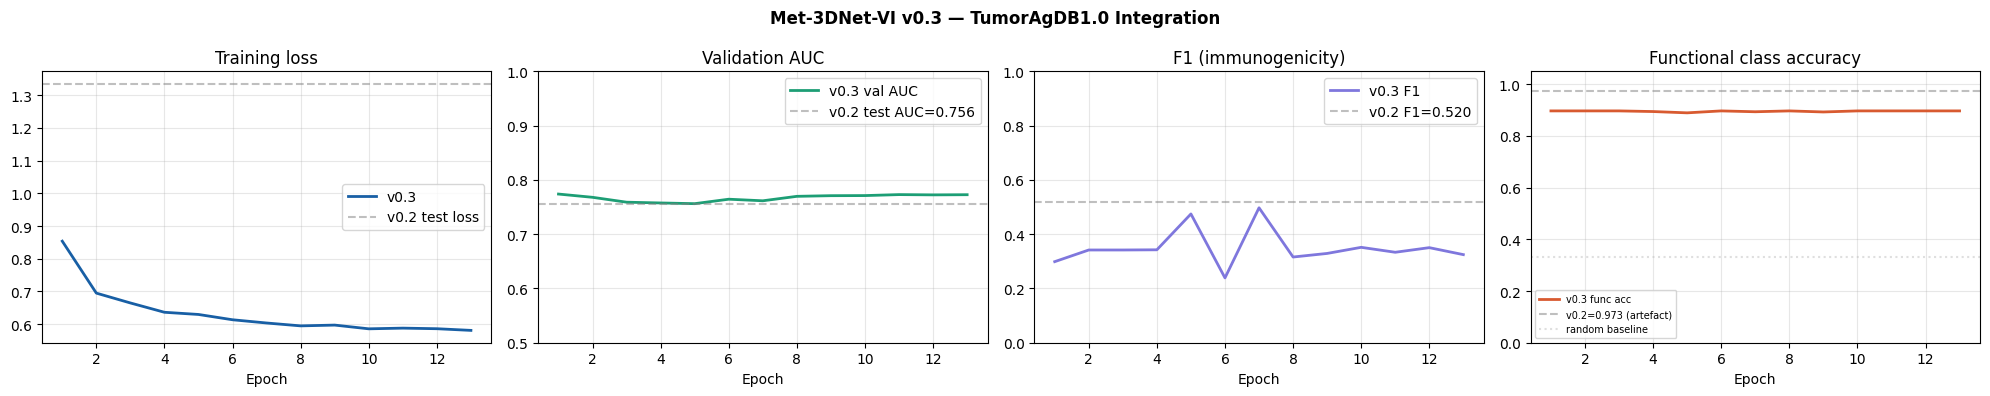

Saved: training_curves_v3.png

LABEL UPGRADE SUMMARY
  v0.2 training data  : 5,593 samples
  v0.3 training data  : 17,270 samples
  New records added   : +11,677
  New activating      : 9,464
  New suppressive     : 0
  New non-immunogenic : 2,615

  v0.2 unknown labels : 5,043 (90.2%)
  v0.3 unknown labels : 7,565 (43.8%)

  Download: best_model_v3.pt + training_history_v3.json


In [9]:
import matplotlib.pyplot as plt

history = hist_data["history"]
epochs  = [h["epoch"]     for h in history]
tr_loss = [h["train_loss"] for h in history]
val_auc = [h["val_auc"]    for h in history]
val_f1  = [h["val_f1"]     for h in history]
val_fa  = [h.get("val_func_acc",0) for h in history]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].plot(epochs, tr_loss, color="#185FA5", lw=2, label="v0.3")
axes[0].axhline(1.3356, ls="--", color="gray", alpha=0.5, label="v0.2 test loss")
axes[0].set_title("Training loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, val_auc, color="#1D9E75", lw=2, label="v0.3 val AUC")
axes[1].axhline(0.7562, ls="--", color="gray", alpha=0.5, label="v0.2 test AUC=0.756")
axes[1].set_ylim(0.5, 1.0); axes[1].set_title("Validation AUC")
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, val_f1, color="#7F77DD", lw=2, label="v0.3 F1")
axes[2].axhline(0.5203, ls="--", color="gray", alpha=0.5, label="v0.2 F1=0.520")
axes[2].set_ylim(0, 1); axes[2].set_title("F1 (immunogenicity)")
axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(epochs, val_fa, color="#D85A30", lw=2, label="v0.3 func acc")
axes[3].axhline(0.9733, ls="--", color="gray", alpha=0.5, label="v0.2=0.973 (artefact)")
axes[3].axhline(0.333, ls=":", color="silver", alpha=0.5, label="random baseline")
axes[3].set_ylim(0, 1.05); axes[3].set_title("Functional class accuracy")
axes[3].legend(fontsize=7); axes[3].grid(alpha=0.3)

for ax in axes: ax.set_xlabel("Epoch")
plt.suptitle(f"Met-3DNet-VI v0.3 — TumorAgDB1.0 Integration",
             fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(os.path.join(WORK_DIR,"training_curves_v3.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_curves_v3.png")

# ── Final summary ────────────────────────────────────────────
print("\n"+"="*55)
print("LABEL UPGRADE SUMMARY")
print("="*55)
print(f"  v0.2 training data  : {len(train_orig):,} samples")
print(f"  v0.3 training data  : {len(train_combined):,} samples")
delta = len(train_combined) - len(train_orig)
print(f"  New records added   : {delta:+,}")
if len(new_data) > 0:
    print(f"  New activating      : {(new_data['functional_class']==2).sum():,}")
    print(f"  New suppressive     : {(new_data['functional_class']==1).sum():,}")
    print(f"  New non-immunogenic : {(new_data['functional_class']==0).sum():,}")
print(f"\n  v0.2 unknown labels : {(train_orig['functional_class']==0).sum():,} "
      f"({(train_orig['functional_class']==0).mean()*100:.1f}%)")
print(f"  v0.3 unknown labels : {(train_combined['functional_class']==0).sum():,} "
      f"({(train_combined['functional_class']==0).mean()*100:.1f}%)")
print(f"\n  Download: best_model_v3.pt + training_history_v3.json")